In [27]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, RobustScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

In [28]:
df = sns.load_dataset('titanic')

leaky = ['alive', 'who', 'adult_male', 'class', 'deck', 'embark_town', 'alone']
df = df.drop(columns=leaky, errors='ignore')

print(list(df.columns))

['survived', 'pclass', 'sex', 'age', 'sibsp', 'parch', 'fare', 'embarked']


In [29]:
X = df.drop(columns=['survived'])
y = df['survived']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

num_cols = ['age', 'sibsp', 'parch', 'fare']
cat_cols = ['sex', 'embarked', 'pclass']

num_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', RobustScaler())
])

cat_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('endcoder', OneHotEncoder(handle_unknown='ignore', drop='first'))
])

preprocessor = ColumnTransformer(transformers=[
    ('num', num_transformer, num_cols),
    ('cat', cat_transformer, cat_cols)
])

In [30]:
logistic_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', LogisticRegression(random_state=42))
])
logistic_pipeline.fit(X_train, y_train)

y_pred_logistic = logistic_pipeline.predict(X_test)

linear_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', LinearRegression())
])
linear_pipeline.fit(X_train, y_train)

y_pred_linear_cont = linear_pipeline.predict(X_test)
y_pred_linear = np.where(y_pred_linear_cont >= 0.5, 1, 0)

In [31]:
metrics = {
    'Index': ['Accuracy', 'Precision', 'Recall', 'F1-score'],
    'Linear Regression': [
        accuracy_score(y_test, y_pred_linear),
        precision_score(y_test, y_pred_linear),
        recall_score(y_test, y_pred_linear),
        f1_score(y_test, y_pred_linear)
    ],
    'Logistic Regression': [
        accuracy_score(y_test, y_pred_logistic),
        precision_score(y_test, y_pred_logistic),
        recall_score(y_test, y_pred_logistic),
        f1_score(y_test, y_pred_logistic)
    ]
}

df_compare = pd.DataFrame(metrics)
print("\nCOMPARE")
print(df_compare.round(4).to_string(index=False))


COMPARE
    Index  Linear Regression  Logistic Regression
 Accuracy             0.8045               0.7989
Precision             0.7833               0.7797
   Recall             0.6812               0.6667
 F1-score             0.7287               0.7188


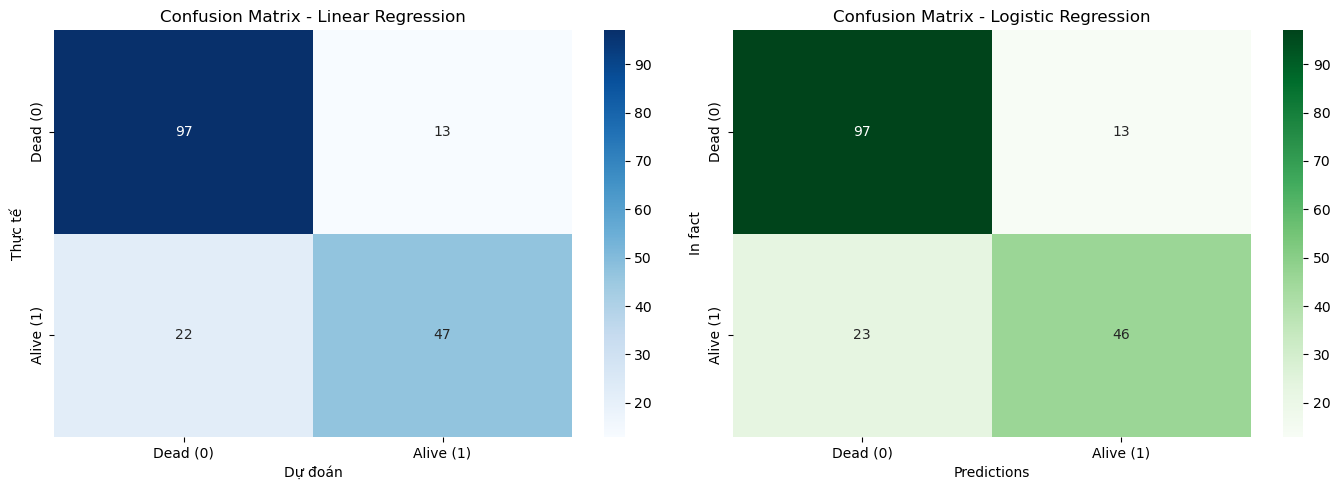

In [32]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

labels = ['Dead (0)', 'Alive (1)']

# Linear Regression
cm_linear = confusion_matrix(y_test, y_pred_linear)
sns.heatmap(cm_linear, annot=True, fmt='d', cmap='Blues', ax=axes[0], xticklabels=labels, yticklabels=labels)
axes[0].set_title('Confusion Matrix - Linear Regression')
axes[0].set_xlabel('Dự đoán')
axes[0].set_ylabel('Thực tế')

# Logistic Regression
cm_logistic = confusion_matrix(y_test, y_pred_logistic)
sns.heatmap(cm_logistic, annot=True, fmt='d', cmap='Greens', ax=axes[1], xticklabels=labels, yticklabels=labels)
axes[1].set_title('Confusion Matrix - Logistic Regression')
axes[1].set_xlabel('Predictions')
axes[1].set_ylabel('In fact')

plt.tight_layout()
plt.show()

Nhận xét: Logistic Regression phù hợp hơn với bài toán này vì Linear Regression dễ bị sụp đổ do giá trị dự đoán có thể nằm ngoài [0, 1] trong khi mình chỉ cần xác định là dead hay alive theo kiểu nhị phân (0 và 1) nên dùng Logistci Regression hợp lý hơn nhờ hàm Sigmoid.